In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,classification_report
import warnings
warnings.filterwarnings('ignore')


In [80]:
columns = ["buying","maint","doors","persons","lug_boot","safety","Evaluation"]

In [81]:
car = pd.read_csv("car.data",header=None,names=columns)
car

,buying,maint,doors,persons,lug_boot,safety,Evaluation
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good


In [82]:
car.head()

,buying,maint,doors,persons,lug_boot,safety,Evaluation
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [83]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   buying      1728 non-null   object
 1   maint       1728 non-null   object
 2   doors       1728 non-null   object
 3   persons     1728 non-null   object
 4   lug_boot    1728 non-null   object
 5   safety      1728 non-null   object
 6   Evaluation  1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [84]:
car.duplicated().value_counts()

False    1728
Name: count, dtype: int64

In [85]:
car.isnull().sum()

buying        0
maint         0
doors         0
persons       0
lug_boot      0
safety        0
Evaluation    0
dtype: int64

In [86]:
car.columns

Index(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety',
       'Evaluation'],
      dtype='object')

In [87]:
from sklearn.preprocessing import LabelEncoder
lab_enc = LabelEncoder()

In [88]:
for i in car.select_dtypes('object'):
    car[i] = lab_enc.fit_transform(car[i])

In [89]:
X = car[['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']]
y = car['Evaluation']

In [90]:
X,y

(      buying  maint  doors  persons  lug_boot  safety
 0          3      3      0        0         2       1
 1          3      3      0        0         2       2
 2          3      3      0        0         2       0
 3          3      3      0        0         1       1
 4          3      3      0        0         1       2
 ...      ...    ...    ...      ...       ...     ...
 1723       1      1      3        2         1       2
 1724       1      1      3        2         1       0
 1725       1      1      3        2         0       1
 1726       1      1      3        2         0       2
 1727       1      1      3        2         0       0
 
 [1728 rows x 6 columns],
 0       2
 1       2
 2       2
 3       2
 4       2
        ..
 1723    1
 1724    3
 1725    2
 1726    1
 1727    3
 Name: Evaluation, Length: 1728, dtype: int64)

In [91]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)

In [92]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((1209, 6), (519, 6), (1209,), (519,))

In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [94]:
svm = SVC(kernel='rbf')
svm.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [95]:
y_pred = svm.predict(X_test)
y_pred[:10]

array([0, 2, 2, 2, 3, 2, 2, 2, 2, 2])

In [96]:
y_test[:10]

643     0
1306    2
960     2
138     2
1184    3
136     2
1406    2
717     2
1568    2
654     2
Name: Evaluation, dtype: int64

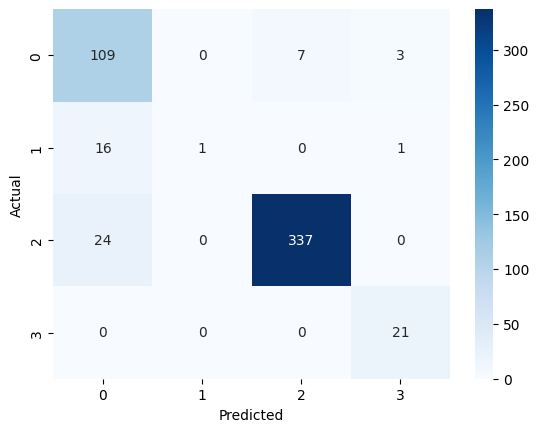

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(conf_mat,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [99]:
conf_mat = confusion_matrix(y_test,y_pred)
conf_mat

array([[109,   0,   7,   3],
       [ 16,   1,   0,   1],
       [ 24,   0, 337,   0],
       [  0,   0,   0,  21]])

In [100]:
print(f"Accuracy : {accuracy_score(y_test,y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test,y_pred,average='weighted')*100:.2f}%")
print(f"Recall   : {recall_score(y_test,y_pred,average='weighted')*100:.2f}%")

print("\nClassification Report:\n")
print(classification_report(y_test,y_pred))

Accuracy : 90.17%
Precision: 91.78%
Recall   : 90.17%

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.92      0.81       119
           1       1.00      0.06      0.11        18
           2       0.98      0.93      0.96       361
           3       0.84      1.00      0.91        21

    accuracy                           0.90       519
   macro avg       0.89      0.73      0.70       519
weighted avg       0.92      0.90      0.89       519



In [102]:
import pickle
with open("evaluation.pkl",'wb') as file:
    pickle.dump(svm,file)